# PBMRS — MVP Notebook
Physics-Based Market Risk Simulator — Core simulation + diagnostics

**Closed feedback loop:**
`(si,t) → mt → Qt → (rt, xt) → (vt, ℓt) → ht → (si,t+1)`

Sections: 1 Setup · 2 State Variables · 3 Diagnostics · 4 Regime Comparison

## 1. Setup & Config

In [1]:
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

sys.path.append("../src")

from pbmrs_core.sim         import SimConfig, SimResult, run_sim, run_ensemble, check_invariants
from pbmrs_core.diagnostics import drawdown, max_drawdown, recovery_time

print("Imports OK")

Imports OK


In [2]:
cfg_path = Path("../configs/base.yaml")
cfg_dict = yaml.safe_load(cfg_path.read_text())
cfg      = SimConfig(**cfg_dict)

print(f"seed={cfg.seed}  n_agents={cfg.n_agents}  timesteps={cfg.timesteps}")
print(f"J={cfg.J}  beta={cfg.beta}  J*beta={cfg.J * cfg.beta:.2f}  "
      f"({'subcritical' if cfg.J * cfg.beta < 1 else 'SUPERCRITICAL'})")
print(f"lam={cfg.lam}  sigma_eps={cfg.sigma_eps}  theta_v={cfg.theta_v}")

seed=42  n_agents=2000  timesteps=2000
J=0.5  beta=1.2  J*beta=0.60  (subcritical)
lam=0.05  sigma_eps=0.01  theta_v=1.0


In [3]:
out = run_sim(cfg)
check_invariants(out, cfg)
print({k: getattr(out, k).shape for k in ["x","v","l","m","Q","r","h","prices"]})

{'x': (2001,), 'v': (2001,), 'l': (2001,), 'm': (2001,), 'Q': (2000,), 'r': (2000,), 'h': (2000,), 'prices': (2001,)}


## 2. State Variable Plots

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Mghou\AppData\Local\Temp\ipykernel_31880\2938387261.py:18: SyntaxWarning: invalid escape sequence '\e'
  axes[2].set_ylabel("Liquidity  $\ell_t$")


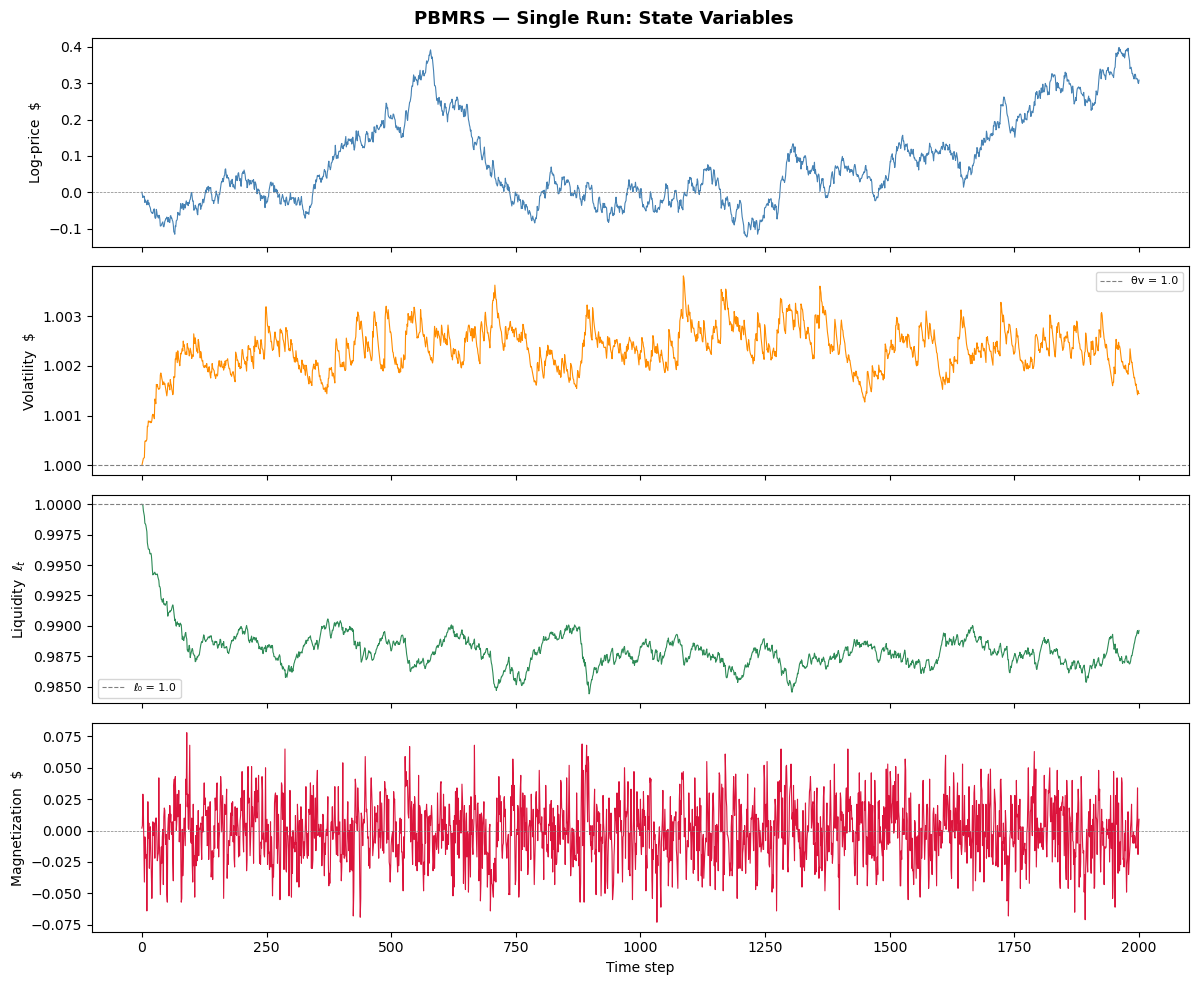

Return std : 0.01014
Mean |m|   : 0.0196
Mean v     : 1.00234
Mean l     : 0.98805


In [4]:
T    = cfg.timesteps
time = np.arange(T + 1)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle("PBMRS — Single Run: State Variables", fontsize=13, fontweight="bold")

axes[0].plot(time, out.x, lw=0.8, color="steelblue")
axes[0].axhline(0, color="grey", lw=0.5, ls="--")
axes[0].set_ylabel("Log-price  $")

axes[1].plot(time, out.v, lw=0.8, color="darkorange")
axes[1].axhline(cfg.theta_v, color="grey", lw=0.8, ls="--", label=f"θv = {cfg.theta_v}")
axes[1].set_ylabel("Volatility  $")
axes[1].legend(fontsize=8)

axes[2].plot(time, out.l, lw=0.8, color="seagreen")
axes[2].axhline(cfg.l0, color="grey", lw=0.8, ls="--", label=f"ℓ₀ = {cfg.l0}")
axes[2].set_ylabel("Liquidity  $\ell_t$")
axes[2].legend(fontsize=8)

axes[3].plot(time, out.m, lw=0.8, color="crimson")
axes[3].axhline(0, color="grey", lw=0.5, ls="--")
axes[3].set_ylabel("Magnetization  $")
axes[3].set_xlabel("Time step")

plt.tight_layout()
plt.show()

print(f"Return std : {out.r.std():.5f}")
print(f"Mean |m|   : {np.abs(out.m).mean():.4f}")
print(f"Mean v     : {out.v.mean():.5f}")
print(f"Mean l     : {out.l.mean():.5f}")

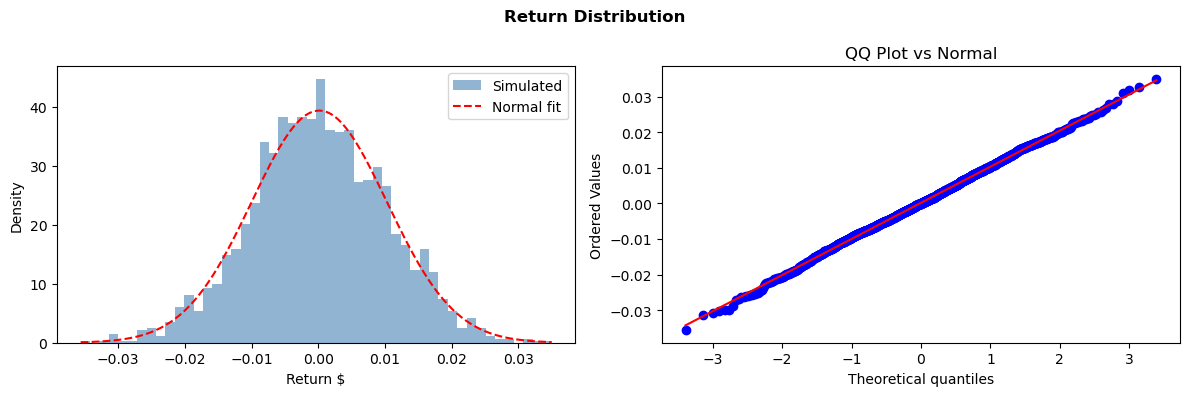

Excess kurtosis: 0.040  (fat tails)


In [5]:
returns = out.r   # named "returns" to avoid collision with loop var in cells 9-12

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Return Distribution", fontsize=12, fontweight="bold")

axes[0].hist(returns, bins=50, density=True, alpha=0.6, color="steelblue", label="Simulated")
xs = np.linspace(returns.min(), returns.max(), 200)
axes[0].plot(xs, stats.norm.pdf(xs, returns.mean(), returns.std()),
             "r--", lw=1.5, label="Normal fit")
axes[0].set_xlabel("Return $")
axes[0].set_ylabel("Density")
axes[0].legend()

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot vs Normal")

plt.tight_layout()
plt.show()

kurt = float(stats.kurtosis(returns))
print(f"Excess kurtosis: {kurt:.3f}  ({'fat tails' if kurt > 0 else 'thin tails'})")

## 3. Diagnostics — Drawdown, Recovery, Fragility

In [6]:
# Spec Eq.7: DD(t) = 1 - St/Mt  where St = exp(xt)
# out.prices = exp(out.x) is pre-computed by run_sim — no redundant exp call
dd  = drawdown(out.prices)
mdd = max_drawdown(out.prices)
rec = recovery_time(out.prices)

print(f"Max drawdown  : {mdd:.4f}  ({mdd * 100:.1f}%)")
if rec is not None:
    print(f"Recovery time : {rec} steps")
else:
    print("Recovery time : did not recover within simulation window")

Max drawdown  : 0.4028  (40.3%)
Recovery time : 746 steps


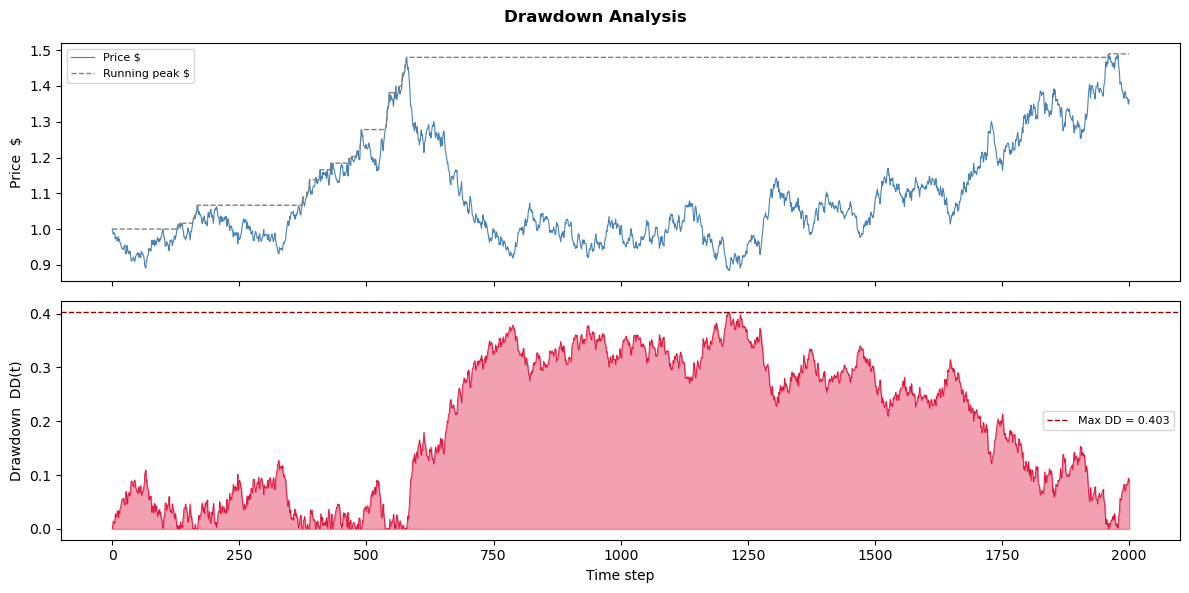

In [7]:
peak = np.maximum.accumulate(out.prices)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Drawdown Analysis", fontsize=12, fontweight="bold")

axes[0].plot(time, out.prices, lw=0.8, color="steelblue", label="Price $")
axes[0].plot(time, peak,       lw=1.0, color="grey", ls="--", label="Running peak $")
axes[0].set_ylabel("Price  $")
axes[0].legend(fontsize=8)

axes[1].fill_between(time, dd, alpha=0.4, color="crimson")
axes[1].plot(time, dd, lw=0.6, color="crimson")
axes[1].axhline(mdd, color="darkred", lw=1.0, ls="--",
                label=f"Max DD = {mdd:.3f}")
axes[1].set_ylabel("Drawdown  DD(t)")
axes[1].set_xlabel("Time step")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

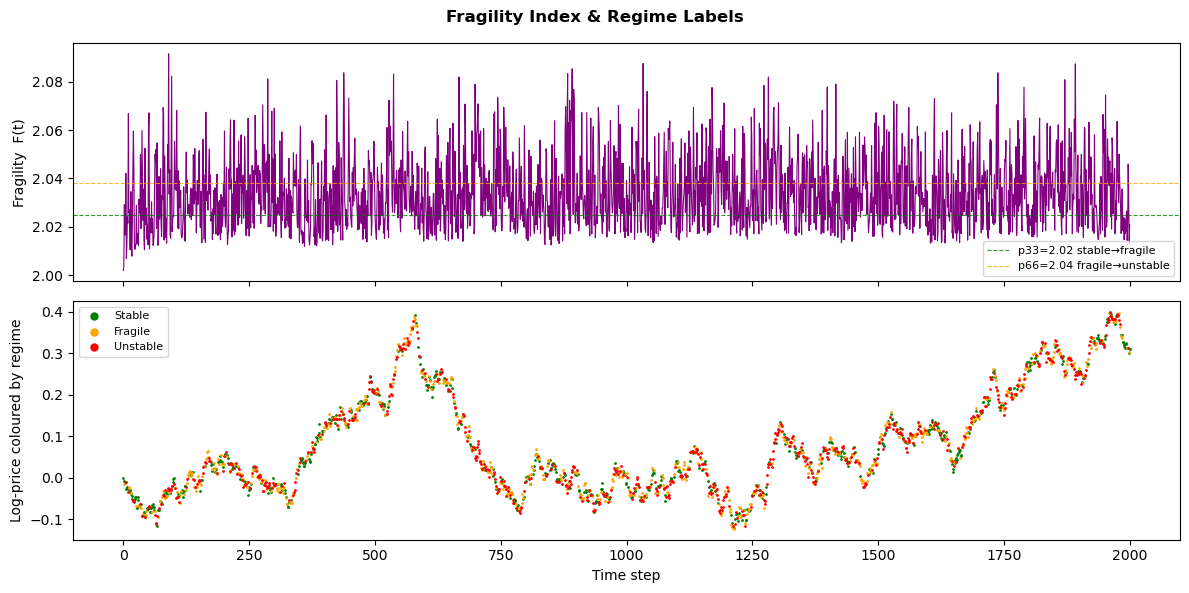

Regime distribution: {'Stable': 660, 'Fragile': 660, 'Unstable': 681}


In [8]:
# ── Named constants (see README §5.3) ──────────────────────────────────────
# Equal weighting: each component contributes comparably when near baseline
FRAGILITY_WEIGHTS = (1.0, 1.0, 1.0)   # (wm, wl, wv)

# Tertile split: bottom third = Stable, middle = Fragile, top third = Unstable
REGIME_THRESHOLDS = (33, 66)           # percentile boundaries

wm, wl, wv = FRAGILITY_WEIGHTS

# README Eq.9: F(t) = wm*|mt| + wl*(l0/lt) + wv*(vt/theta_v)
F = (wm * np.abs(out.m)
   + wl * (cfg.l0 / out.l)
   + wv * (out.v / cfg.theta_v))

p33    = np.percentile(F, REGIME_THRESHOLDS[0])
p66    = np.percentile(F, REGIME_THRESHOLDS[1])
regime = np.where(F < p33, 0, np.where(F < p66, 1, 2))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Fragility Index & Regime Labels", fontsize=12, fontweight="bold")

axes[0].plot(time, F, lw=0.8, color="purple")
axes[0].axhline(p33, color="green",  lw=0.8, ls="--", alpha=0.8,
                label=f"p33={p33:.2f} stable→fragile")
axes[0].axhline(p66, color="orange", lw=0.8, ls="--", alpha=0.8,
                label=f"p66={p66:.2f} fragile→unstable")
axes[0].set_ylabel("Fragility  F(t)")
axes[0].legend(fontsize=8)

COLOUR_MAP = {0: "green", 1: "orange", 2: "red"}
LABEL_MAP  = {0: "Stable", 1: "Fragile", 2: "Unstable"}
for rid in [0, 1, 2]:
    mask = regime == rid
    axes[1].scatter(time[mask], out.x[mask], s=1, c=COLOUR_MAP[rid], label=LABEL_MAP[rid])
axes[1].set_ylabel("Log-price coloured by regime")
axes[1].set_xlabel("Time step")
axes[1].legend(fontsize=8, markerscale=5)

plt.tight_layout()
plt.show()

counts = {LABEL_MAP[k]: int((regime==k).sum()) for k in range(3)}
print("Regime distribution:", counts)

## 4. Regime Comparison — J × β Sweep

In [9]:
# Named constants — Issue 7
# J_SWEEP: last value 0.82 ≈ 1/beta = 0.833 (near-critical boundary)
J_SWEEP   = [0.3, 0.5, 0.7, 0.82]
PALETTE   = ["steelblue", "seagreen", "darkorange", "crimson"]
HIST_BINS = 50   # consistent across all histogram plots

results = {}

for J_val in J_SWEEP:
    cfg_j          = SimConfig(**{**cfg_dict, "J": J_val, "seed": 42})
    results[J_val] = run_sim(cfg_j)
    res            = results[J_val]   # loop var is "res", not "r"
    print(f"J={J_val:.2f}  J*beta={J_val*cfg.beta:.2f}  "
          f"max|m|={np.abs(res.m).max():.3f}  "
          f"mean_v={res.v.mean():.5f}  "
          f"min_l={res.l.min():.4f}")

J=0.30  J*beta=0.36  max|m|=0.073  mean_v=1.00229  min_l=0.9852
J=0.50  J*beta=0.60  max|m|=0.078  mean_v=1.00234  min_l=0.9844
J=0.70  J*beta=0.84  max|m|=0.083  mean_v=1.00241  min_l=0.9832
J=0.82  J*beta=0.98  max|m|=0.090  mean_v=1.00248  min_l=0.9819


<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Mghou\AppData\Local\Temp\ipykernel_31880\1544577305.py:17: SyntaxWarning: invalid escape sequence '\e'
  axes[2].set_ylabel("Liquidity  $\ell_t$")


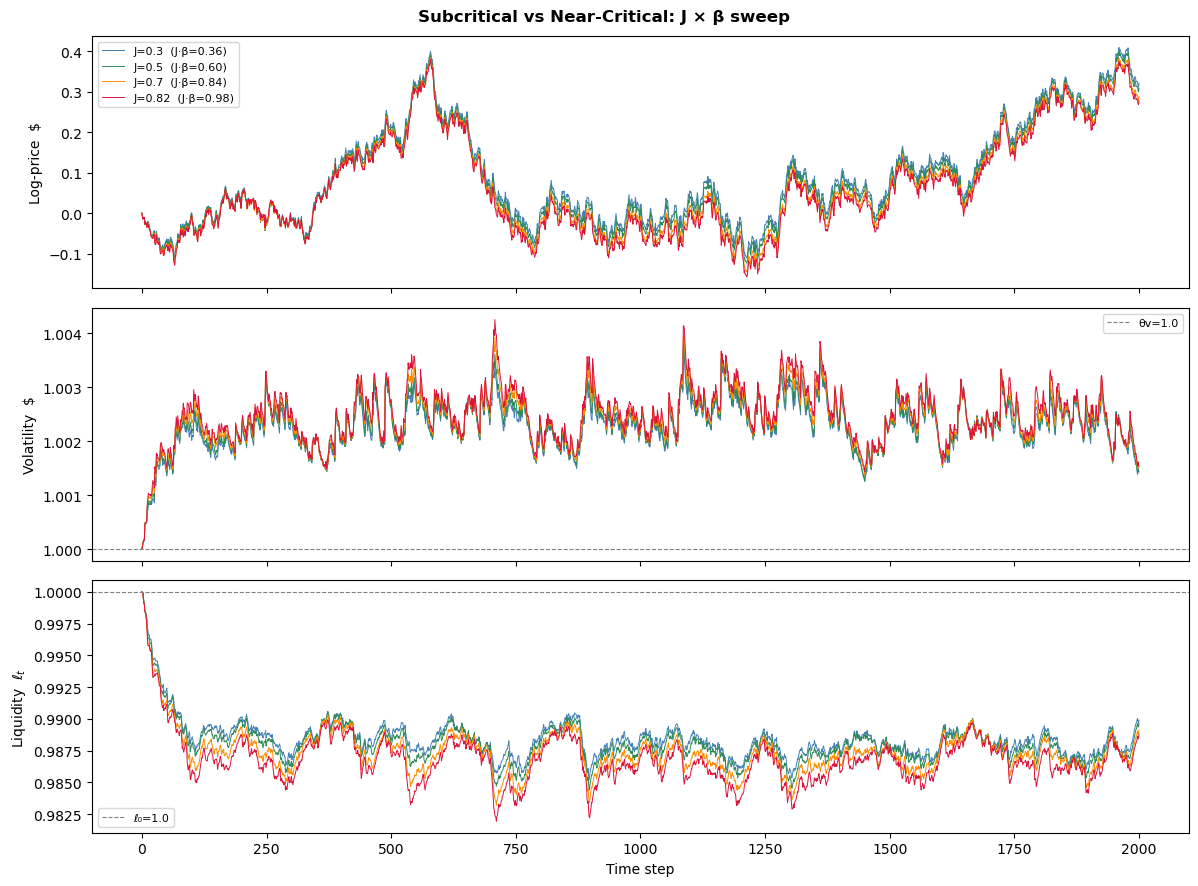

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Subcritical vs Near-Critical: J × β sweep",
             fontsize=12, fontweight="bold")

for J_val, colour in zip(J_SWEEP, PALETTE):
    res   = results[J_val]
    label = f"J={J_val}  (J·β={J_val*cfg.beta:.2f})"
    axes[0].plot(res.x, lw=0.7, color=colour, label=label)
    axes[1].plot(res.v, lw=0.7, color=colour)
    axes[2].plot(res.l, lw=0.7, color=colour)

axes[0].set_ylabel("Log-price  $")
axes[0].legend(fontsize=8, loc="upper left")
axes[1].set_ylabel("Volatility  $")
axes[1].axhline(cfg.theta_v, color="grey", lw=0.8, ls="--", label=f"θv={cfg.theta_v}")
axes[1].legend(fontsize=8)
axes[2].set_ylabel("Liquidity  $\ell_t$")
axes[2].axhline(cfg.l0, color="grey", lw=0.8, ls="--", label=f"ℓ₀={cfg.l0}")
axes[2].set_xlabel("Time step")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

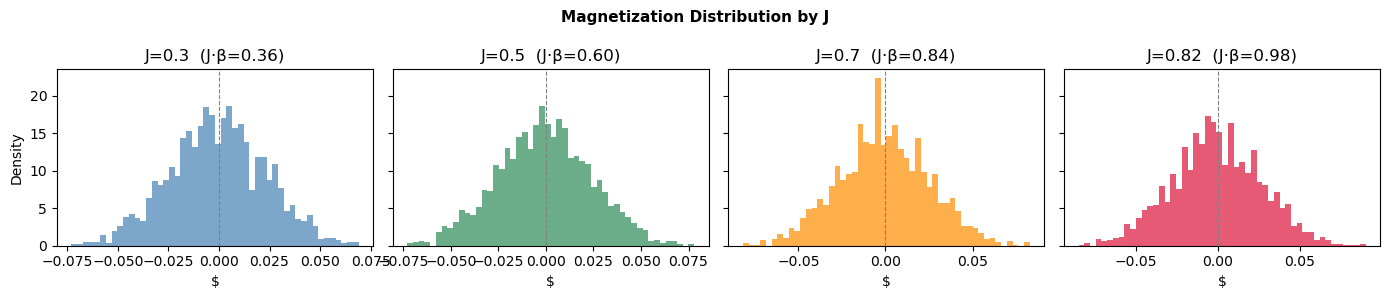

In [11]:
fig, axes = plt.subplots(1, len(J_SWEEP), figsize=(14, 3), sharey=True)
fig.suptitle("Magnetization Distribution by J", fontsize=11, fontweight="bold")

for ax, (J_val, colour) in zip(axes, zip(J_SWEEP, PALETTE)):
    ax.hist(results[J_val].m, bins=HIST_BINS, density=True, color=colour, alpha=0.7)
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(f"J={J_val}  (J·β={J_val*cfg.beta:.2f})")
    ax.set_xlabel("$")
axes[0].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [12]:
print(f"{'J':>5}  {'J*β':>5}  {'RetStd':>8}  {'MDD':>7}  {'MeanV':>8}  {'MinL':>7}")
print("-" * 50)
for J_val in J_SWEEP:
    res = results[J_val]
    mdd = max_drawdown(res.prices)   # uses pre-computed prices field
    print(f"{J_val:>5.2f}  {J_val*cfg.beta:>5.2f}  "
          f"{res.r.std():>8.5f}  {mdd:>7.4f}  "
          f"{res.v.mean():>8.5f}  {res.l.min():>7.4f}")

    J    J*β    RetStd      MDD     MeanV     MinL
--------------------------------------------------
 0.30   0.36   0.01014   0.3993   1.00229   0.9852
 0.50   0.60   0.01014   0.4028   1.00234   0.9844
 0.70   0.84   0.01015   0.4105   1.00241   0.9832
 0.82   0.98   0.01016   0.4153   1.00248   0.9819
